--- Evaluating Logistic Regression ---
AUROC: 0.6928 ± 0.0252
Sensitivity (Recall): 0.6455 ± 0.0319



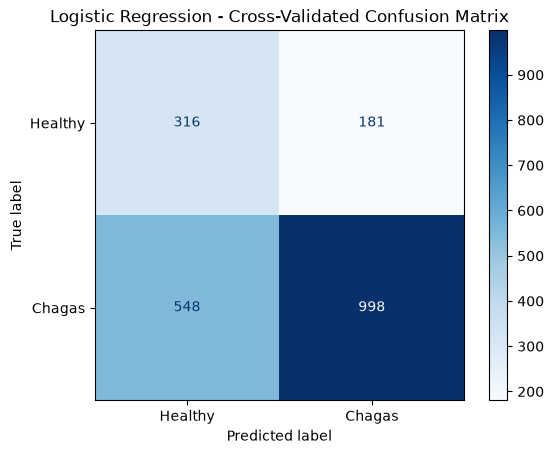

--- Evaluating Random Forest ---
AUROC: 0.7859 ± 0.0246
Sensitivity (Recall): 0.8732 ± 0.0251



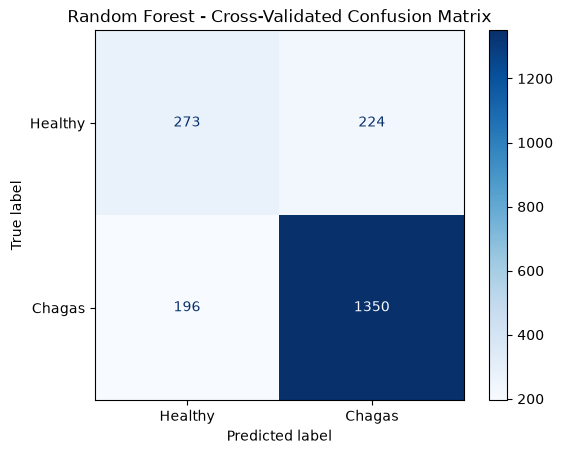

--- Evaluating XGBoost ---
AUROC: 0.7649 ± 0.0283
Sensitivity (Recall): 0.8648 ± 0.0203



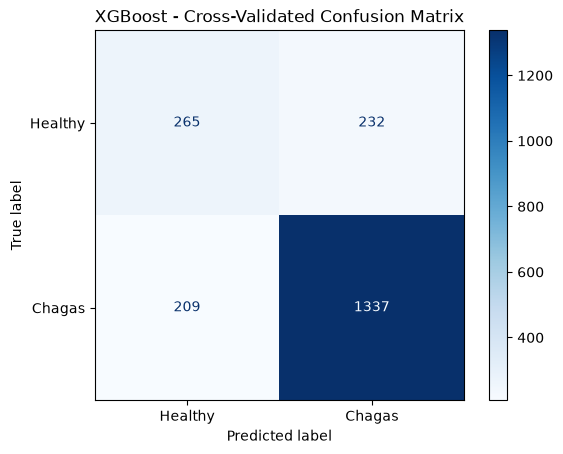

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GroupKFold, cross_validate, cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Load the data
df = pd.read_csv('ecg_features_expanded.csv')

# Drop the capitalized target and patient ID columns
X = df.drop(columns=['Label', 'Patient_ID'])
y = df['Label']
groups = df['Patient_ID']

# Check if 'Sex' needs to be converted to numbers (e.g. 'M'/'F' to 1/0)
# This prevents Scikit-Learn from crashing if it sees strings
X = pd.get_dummies(X, drop_first=True, dtype=float)

# 2. Calculate the imbalance ratio for XGBoost
neg_count = (y == 0).sum()
pos_count = (y == 1).sum()
imbalance_ratio = neg_count / pos_count

# 3. Initialize GroupKFold (Patient-level splitting)
gkf = GroupKFold(n_splits=5)

# 4. Define the models to test
models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(scale_pos_weight=imbalance_ratio, eval_metric='auc', random_state=42)
}

# 5. Define the standard metrics to track
scoring = ['roc_auc', 'accuracy', 'recall', 'precision']

# 6. Run the evaluation loop for each model
for name, model in models.items():
    print(f"--- Evaluating {name} ---")
    
    # Run cross-validation
    cv_results = cross_validate(model, X, y, groups=groups, cv=gkf, scoring=scoring)
    
    # Print the requested Mean ± Standard Deviation
    auc_mean = cv_results['test_roc_auc'].mean()
    auc_std = cv_results['test_roc_auc'].std()
    recall_mean = cv_results['test_recall'].mean()
    recall_std = cv_results['test_recall'].std()
    
    print(f"AUROC: {auc_mean:.4f} ± {auc_std:.4f}")
    print(f"Sensitivity (Recall): {recall_mean:.4f} ± {recall_std:.4f}\n")
    
    # Generate Predictions for the Confusion Matrix
    y_pred_cv = cross_val_predict(model, X, y, groups=groups, cv=gkf)
    
    # Plot the Confusion Matrix
    cm = confusion_matrix(y, y_pred_cv)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Healthy", "Chagas"])
    disp.plot(cmap='Blues')
    plt.title(f"{name} - Cross-Validated Confusion Matrix")
    plt.show()

In [6]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, cross_val_predict

# --- PART 1: Hyperparameter Tuning for XGBoost ---
print("--- Tuning XGBoost ---")

# Define the grid of hyperparameters to search through
param_grid = {
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [100, 200, 300, 500],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

# Initialize the base XGBoost model
# Note: Ensure 'imbalance_ratio' and 'gkf' are still in memory from the previous cell
xgb_base = XGBClassifier(scale_pos_weight=imbalance_ratio, eval_metric='auc', random_state=42)

# Set up the randomized search to optimize for 'recall' (minimizing False Negatives)
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=15,          # Tests 15 random combinations (increase if you have more compute time)
    scoring='recall',   # Optimize specifically for sensitivity 
    cv=gkf,
    random_state=42,
    n_jobs=-1           # Uses all available CPU cores
)

# Fit the search using GroupKFold to prevent patient leakage
random_search.fit(X, y, groups=groups)

print("Best Parameters Found:")
for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")

best_xgb = random_search.best_estimator_

# --- PART 2: The 5% Risk Triage Ranking ---
print("\n--- Generating 5% Clinical Triage Ranking ---")

# Get continuous probability predictions (Probability of Chagas = Class 1)
# cross_val_predict ensures predictions are made on out-of-fold data
y_probs = cross_val_predict(best_xgb, X, y, groups=groups, cv=gkf, method='predict_proba')[:, 1]

# Map predictions back to the original patient IDs
results_df = pd.DataFrame({
    'Patient_ID': groups,
    'True_Label': y,
    'Risk_Probability': y_probs
})

# Aggregate risk scores per patient (in case there are multiple ECG rows per patient)
patient_risk = results_df.groupby('Patient_ID').agg(
    True_Label=('True_Label', 'max'),
    Mean_Risk_Probability=('Risk_Probability', 'mean')
).reset_index()

# Sort the patients from highest risk to lowest risk
patient_risk_sorted = patient_risk.sort_values(by='Mean_Risk_Probability', ascending=False)

# Calculate the 5% threshold
total_patients = len(patient_risk_sorted)
top_5_percent_limit = int(total_patients * 0.05)

# Slice the dataframe to get only the patients the clinic will actually test
triage_group = patient_risk_sorted.head(top_5_percent_limit)

print(f"Total Unique Patients: {total_patients}")
print(f"Top 5% Testing Budget Limits Us To: {top_5_percent_limit} patients\n")

print("Top 10 Highest Risk Patients (Triage Priority):")
print(triage_group.head(10).to_string(index=False))

# Optional: Calculate how many of the true positive cases we caught in our 5% net
caught_cases = triage_group['True_Label'].sum()
total_actual_chagas = patient_risk['True_Label'].sum()
print(f"\nOf the {top_5_percent_limit} patients we tested, {caught_cases} actually had Chagas.")
print(f"Total Chagas patients in dataset: {total_actual_chagas}")

--- Tuning XGBoost ---
Best Parameters Found:
  subsample: 0.8
  n_estimators: 500
  max_depth: 7
  learning_rate: 0.05
  colsample_bytree: 0.6

--- Generating 5% Clinical Triage Ranking ---
Total Unique Patients: 2043
Top 5% Testing Budget Limits Us To: 102 patients

Top 10 Highest Risk Patients (Triage Priority):
 Patient_ID  True_Label  Mean_Risk_Probability
     417536           1               0.998164
     289483           1               0.998009
     415765           1               0.997921
     377588           1               0.997821
     267647           1               0.997503
     830663           1               0.997248
     576885           1               0.997088
        196           0               0.996758
     528017           1               0.996704
     448563           1               0.996695

Of the 102 patients we tested, 92 actually had Chagas.
Total Chagas patients in dataset: 1546
